Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset Path: /kaggle/input/creditcardfraud

Dataset Loaded Successfully

Rows : 284807
Columns : 31

Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Records : 1081

Shape After Removing Duplicates
(283726, 31)


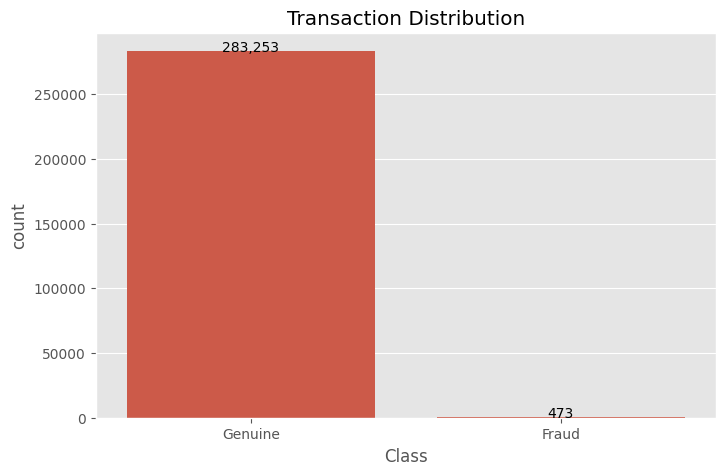


Fraud Rate : 0.1667%
Genuine Rate : 99.8333%


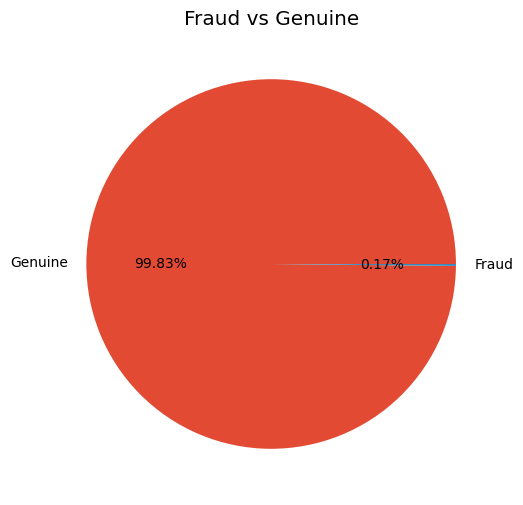

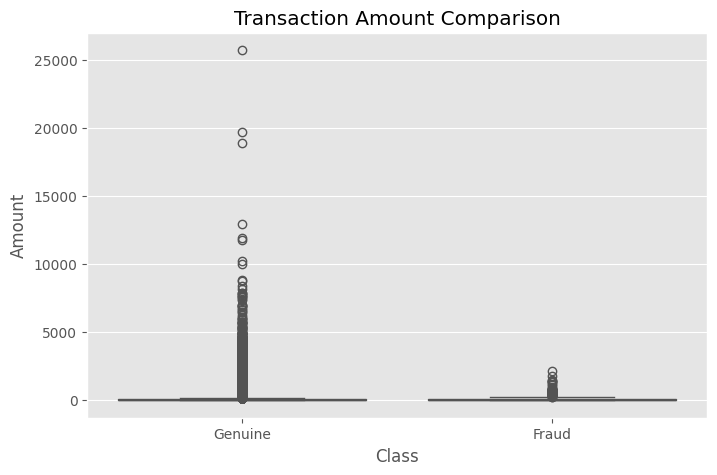


Performing Feature Engineering...
Feature Engineering Completed

Feature Matrix Shape : (283726, 34)

Training Shape : (226980, 34)
Testing Shape : (56746, 34)

Applying SMOTE...

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64

Training Logistic Regression...
Done

Training Random Forest...
Done

Logistic Regression
Accuracy  : 0.9727
Precision : 0.0512
Recall    : 0.8737
F1 Score  : 0.0967

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746


Random Forest
Accuracy  : 0.9980
Precision : 0.4535
Recall    : 0.8211
F1 Score  : 0.5843

Classification Report

              precision    recall  f1-score   su

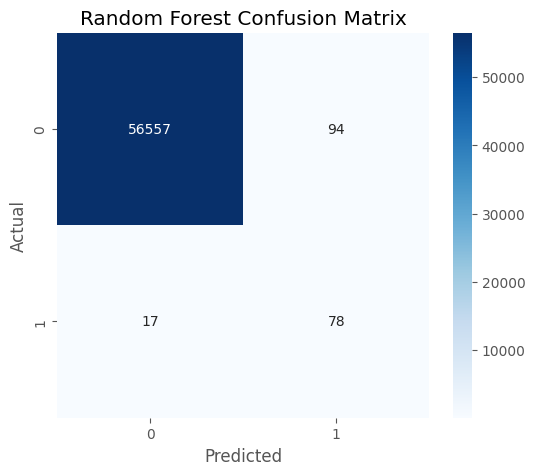

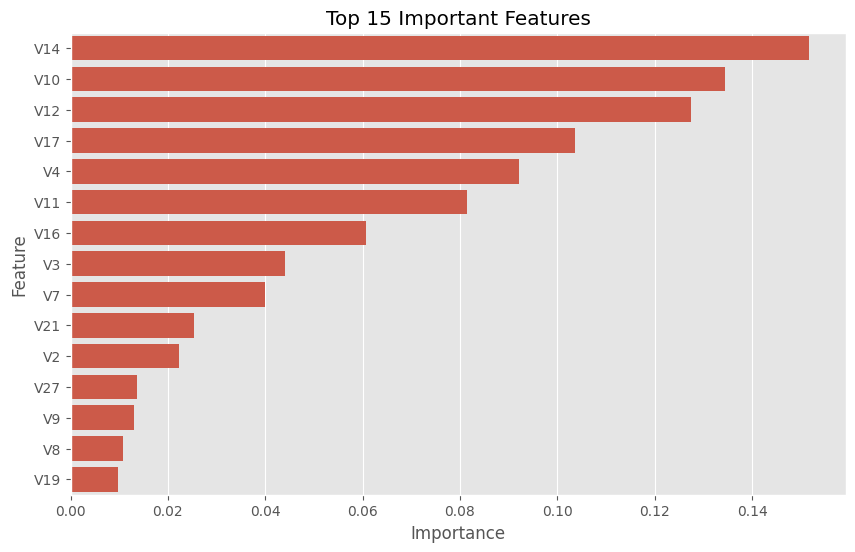


Top Important Features
   Feature  Importance
14     V14    0.151616
10     V10    0.134494
12     V12    0.127370
17     V17    0.103681
4       V4    0.092153
11     V11    0.081480
16     V16    0.060778
3       V3    0.044101
7       V7    0.039869
21     V21    0.025451
2       V2    0.022232
27     V27    0.013733
9       V9    0.013027
8       V8    0.010756
19     V19    0.009804

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.972685   0.051203  0.873684  0.096737
1        Random Forest  0.998044   0.453488  0.821053  0.584270

BUSINESS INSIGHTS
Total Transactions : 283,726
Fraud Transactions : 473
Fraud Rate : 0.1667%
Potential Fraud Amount : ₹58,591.39

Sample Prediction
Genuine Transaction

Project Completed Successfully


In [4]:
# =====================================================
# CREDIT CARD FRAUD DETECTION PROJECT
# Fast + Professional + Error Free Version
# =====================================================

# Install Dataset Package
!pip install kagglehub -q

import kagglehub
import os
import warnings
warnings.filterwarnings("ignore")

print("Downloading Dataset...")

dataset_path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

print("Dataset Path:", dataset_path)

# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

plt.style.use("ggplot")

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv(
    os.path.join(dataset_path, "creditcard.csv")
)

print("\nDataset Loaded Successfully")

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

# =====================================================
# DATA CLEANING
# =====================================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records :", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape After Removing Duplicates")
print(df.shape)

# =====================================================
# EDA
# =====================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="Class",
    data=df
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center"
    )

plt.xticks(
    [0,1],
    ["Genuine","Fraud"]
)

plt.title("Transaction Distribution")
plt.show()

# Fraud Rate

fraud_rate = df["Class"].mean()*100

print(f"\nFraud Rate : {fraud_rate:.4f}%")
print(f"Genuine Rate : {100-fraud_rate:.4f}%")

# Pie Chart

plt.figure(figsize=(6,6))

plt.pie(
    df["Class"].value_counts(),
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%"
)

plt.title("Fraud vs Genuine")
plt.show()

# Amount Comparison

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.xticks(
    [0,1],
    ["Genuine","Fraud"]
)

plt.title("Transaction Amount Comparison")
plt.show()

# =====================================================
# FEATURE ENGINEERING
# =====================================================

print("\nPerforming Feature Engineering...")

df["Amount_Log"] = np.log1p(df["Amount"])

df["Hour"] = (df["Time"] // 3600) % 24

df["High_Value_Transaction"] = np.where(
    df["Amount"] >
    df["Amount"].quantile(0.95),
    1,
    0
)

df["Micro_Transaction"] = np.where(
    df["Amount"] < 5,
    1,
    0
)

print("Feature Engineering Completed")

# =====================================================
# FEATURE SELECTION
# =====================================================

y = df["Class"]

X = df.drop(
    columns=["Class"]
)

X = X.select_dtypes(
    include=np.number
)

print("\nFeature Matrix Shape :", X.shape)

# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# =====================================================
# HANDLE CLASS IMBALANCE
# =====================================================

print("\nApplying SMOTE...")

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

# =====================================================
# TRAIN MODELS
# =====================================================

print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

print("Done")

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Done")

# =====================================================
# PREDICTIONS
# =====================================================

lr_pred = lr_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

# =====================================================
# EVALUATION FUNCTION
# =====================================================

def evaluate_model(
    name,
    y_true,
    y_pred
):

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(
        f"Accuracy  : {accuracy_score(y_true,y_pred):.4f}"
    )

    print(
        f"Precision : {precision_score(y_true,y_pred):.4f}"
    )

    print(
        f"Recall    : {recall_score(y_true,y_pred):.4f}"
    )

    print(
        f"F1 Score  : {f1_score(y_true,y_pred):.4f}"
    )

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

# =====================================================
# RESULTS
# =====================================================

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

print("\nTop Important Features")
print(importance)

# =====================================================
# MODEL COMPARISON
# =====================================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred)
    ]
})

print("\nModel Comparison")
print(comparison)

# =====================================================
# BUSINESS INSIGHTS
# =====================================================

print("\nBUSINESS INSIGHTS")
print("="*50)

print(
    f"Total Transactions : {len(df):,}"
)

print(
    f"Fraud Transactions : {df['Class'].sum():,}"
)

print(
    f"Fraud Rate : {fraud_rate:.4f}%"
)

print(
    f"Potential Fraud Amount : ₹{df[df['Class']==1]['Amount'].sum():,.2f}"
)

# =====================================================
# SAMPLE PREDICTION
# =====================================================

sample = X.iloc[[0]]

sample_scaled = scaler.transform(
    sample
)

prediction = rf_model.predict(
    sample_scaled
)

print("\nSample Prediction")

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Genuine Transaction")

print("\nProject Completed Successfully")